## Step 0 — Setup & model loading

Imports, repo root, FastF1 cache. `PitAgentCFG` loads five model artefacts — the
three N15 quantile regressors (P05/P50/P95 physical stop duration), the N16
undercut LightGBM classifier, and its Platt calibrator — plus the two JSON configs
that carry feature lists, thresholds, and the circuit traversal lookup.

Two aggregate lookup tables are computed at startup from the N16 training parquet
(`undercut_clean.parquet`): `circuit_undercut_rate` and `team_x_undercut_rate`.
These are pre-aggregated means that would otherwise be unavailable at inference time.
The N15 `team_year_median` feature — median physical stop duration per team × year —
defaults to a global constant of 2.8 s (center of the [2.0, 4.5 s] training range)
since the per-team breakdown was not exported separately; the impact on P50 accuracy
is marginal given it ranks low in N15's permutation importance.

Models to load:

| File | Source | Contents |
|---|---|---|
| `pit_prediction/hist_pit_p05_v1.pkl` | N15 | HistGBT P05 physical stop |
| `pit_prediction/hist_pit_p50_v1.pkl` | N15 | HistGBT P50 physical stop |
| `pit_prediction/hist_pit_p95_v1.pkl` | N15 | HistGBT P95 physical stop |
| `pit_prediction/model_config.json` | N15 | Features, circuit traversal lookup, team LabelEncoder classes |
| `pit_prediction/lgbm_undercut_v1.pkl` | N16 | LightGBM undercut classifier |
| `pit_prediction/calibrator_undercut_v1.pkl` | N16 | Platt calibrator (val 2024) |
| `pit_prediction/model_config_undercut_v1.json` | N16 | Features, threshold, dry compound list |


In [26]:
import json, sys
from dataclasses import dataclass, field
from pathlib import Path

import re
import fastf1
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# Module-level globals — populated by setup_smoke_test_session() before tool invocation
LAPS: pd.DataFrame = pd.DataFrame()
SESSION_META: dict = {}

# Compound allocation per race — keys follow 'YYYY_GP Name' pattern (e.g. '2025_Bahrain Grand Prix')
_tire_compounds_path = repo_root / "data" / "tire_compounds_by_race.json"
TIRE_COMPOUNDS: dict = json.loads(_tire_compounds_path.read_text(encoding="utf-8")) if _tire_compounds_path.exists() else {}

# Team name aliases — FastF1 2025 uses "Racing Bulls"; N15 encoder was trained on "RB"
_TEAM_ALIASES: dict[str, str] = {"Racing Bulls": "RB"}


In [27]:
@dataclass
class PitAgentCFG:
    """Runtime configuration for the Pit Strategy Agent.

    Loads three N15 quantile regressors (physical stop duration P05/P50/P95), the
    N16 undercut LightGBM classifier with its Platt calibrator, and both JSON
    configs. All models are loaded with joblib — required on Windows paths with
    non-ASCII characters that break LightGBM's native save_model.

    circuit_traversal maps GP name to the estimated pit lane traversal time (s);
    subtracting it from the total pit stop yields physical_stop_est, the N15 target.
    team_encoder is a sklearn LabelEncoder reconstructed from the classes stored in
    model_config.json — it converts team name strings to integer codes for N15.
    team_year_median is a per-team×year fallback constant rather than a per-combination
    lookup because the N15 training medians were not exported; the feature has low
    permutation importance and the approximation is adequate for agent-level decisions.

    circuit_undercut_rate and team_x_undercut_rate are aggregated from the N16
    training parquet at startup so that undercut feature construction at inference
    time does not require re-loading the full dataset on every call.

    undercut_threshold (0.522) is the F1-optimal threshold from N16 Optuna tuning.
    dry_compounds lists the compound names for which the N16 model is valid; calls
    with INTERMEDIATE or WET are rejected early.

    Attributes:
        model_name: LM Studio local model identifier for the ReAct agent LLM.
                    Must match the model currently loaded in LM Studio. Does not
                    affect any ML inference — only the LLM synthesis step in Step 3.
        team_year_median_fallback: Global fallback in seconds for the N15
                                   team_year_median feature when per-team×year
                                   data is unavailable. Set to 2.8 s, the centre
                                   of the [2.0, 4.5 s] normal-stop training range.
    """

    model_name: str = "local-model"
    team_year_median_fallback: float = 2.8  # global fallback — see docstring

    def __post_init__(self):
        root = Path.cwd()
        while not (root / ".git").exists():
            root = root.parent

        fastf1.Cache.enable_cache(str(root / "data" / "cache" / "fastf1"))

        self.export_dir = root / "data" / "models" / "agents"
        self.export_dir.mkdir(parents=True, exist_ok=True)

        # --- N15: pit duration models ---
        _pit_dir = root / "data" / "models" / "pit_prediction"
        self.pit_p05_model = joblib.load(_pit_dir / "hist_pit_p05_v1.pkl")
        self.pit_p50_model = joblib.load(_pit_dir / "hist_pit_p50_v1.pkl")
        self.pit_p95_model = joblib.load(_pit_dir / "hist_pit_p95_v1.pkl")

        with open(_pit_dir / "model_config.json") as f:
            pit_cfg = json.load(f)

        self.pit_features: list[str]       = pit_cfg["features"]
        self.circuit_traversal: dict       = pit_cfg["circuit_traversal_lookup"]

        # Reconstruct LabelEncoder for 'team' feature from saved class list
        le = LabelEncoder()
        le.classes_ = np.array(pit_cfg["label_encoder_classes"]["team"])
        self.team_encoder: LabelEncoder = le

        # --- N16: undercut model ---
        self.undercut_model      = joblib.load(_pit_dir / "lgbm_undercut_v1.pkl")
        self.undercut_calibrator = joblib.load(_pit_dir / "calibrator_undercut_v1.pkl")

        with open(_pit_dir / "model_config_undercut_v1.json") as f:
            uc_cfg = json.load(f)

        self.undercut_features: list[str]  = uc_cfg["features"]
        self.undercut_threshold: float     = uc_cfg["best_threshold"]
        self.dry_compounds: list[str]      = uc_cfg["dry_compounds"]

        # --- Aggregate lookups from N16 training parquet ---
        _uc_parquet = root / "data" / "processed" / "undercut_labeled" / "undercut_clean.parquet"
        _uc_df = pd.read_parquet(_uc_parquet)
        self.circuit_undercut_rate: dict = (
            _uc_df.groupby("GP_Name")["undercut_success"].mean().to_dict()
        )
        self.team_x_undercut_rate: dict = (
            _uc_df.groupby("Team_X")["undercut_success"].mean().to_dict()
        )

In [28]:
CFG = PitAgentCFG()

print(f"N15 P50 model      : {type(CFG.pit_p50_model).__name__}")
print(f"N15 features       ({len(CFG.pit_features)}): {CFG.pit_features}")
print(f"N15 team classes   ({len(CFG.team_encoder.classes_)}): {list(CFG.team_encoder.classes_)}")
print(f"Circuit traversal  : {len(CFG.circuit_traversal)} circuits | Bahrain={CFG.circuit_traversal.get('Bahrain Grand Prix', 'N/A'):.2f}s")
print()
print(f"N16 undercut model : {type(CFG.undercut_model).__name__}")
print(f"N16 features       ({len(CFG.undercut_features)}): {CFG.undercut_features}")
print(f"N16 threshold      : {CFG.undercut_threshold}")
print(f"Dry compounds      : {CFG.dry_compounds}")
print()
print(f"circuit_undercut_rate : {len(CFG.circuit_undercut_rate)} circuits | Bahrain={CFG.circuit_undercut_rate.get('Bahrain Grand Prix', 'N/A'):.3f}")
print(f"team_x_undercut_rate  : {len(CFG.team_x_undercut_rate)} teams")
print(f"team_year_median fallback : {CFG.team_year_median_fallback} s")
print(f"EXPORT_DIR         : {CFG.export_dir}")


N15 P50 model      : HistGradientBoostingRegressor
N15 features       (9): ['team', 'year', 'tyre_life_in', 'lap_number', 'compound_id', 'compound_change', 'under_sc', 'tight_pit_box', 'team_year_median']
N15 team classes   (12): ['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'RB', 'Red Bull Racing', 'Williams']
Circuit traversal  : 24 circuits | Bahrain=22.67s

N16 undercut model : LGBMClassifier
N16 features       (13): ['pos_gap', 'Lap_gap', 'tyre_life_diff', 'TyreLife_X', 'TyreLife_Y', 'compound_x_id', 'compound_y_id', 'compound_delta', 'pit_delta_X', 'lap_race_pct', 'pos_X_before', 'circuit_undercut_rate', 'team_x_undercut_rate']
N16 threshold      : 0.522
Dry compounds      : ['HARD', 'MEDIUM', 'SOFT']

circuit_undercut_rate : 24 circuits | Bahrain=0.360
team_x_undercut_rate  : 13 teams
team_year_median fallback : 2.8 s
EXPORT_DIR         : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\dat

### Step 0 results

| Artefact | Type | Details |
|---|---|---|
| N15 P05/P50/P95 | HistGradientBoostingRegressor | 9 features — `team` LabelEncoded, `team_year_median` global fallback 2.8 s |
| N16 undercut | LGBMClassifier | 13 features, threshold=0.522, dry compounds only |
| N16 calibrator | LogisticRegression (Platt) | fitted val 2024 |
| circuit_traversal | dict | 24 circuits — Bahrain=22.67 s |
| circuit_undercut_rate | dict | 24 circuits — Bahrain=0.360 |
| team_x_undercut_rate | dict | 13 teams |

All five model artefacts loaded via joblib. The N15 team `LabelEncoder` is
reconstructed from the class list in `model_config.json` — no separate `.pkl`
needed. The two undercut rate lookups are computed once at startup from
`undercut_clean.parquet` (1 032 pairs, 2023–2024) and held in `CFG` for the
lifetime of the agent.


---

## Step 1 — `PitStrategyOutput` dataclass + feature helpers

Defines the agent's output structure and the feature engineering pipeline that
converts FastF1 lap data into the exact feature sets expected by N15 (9 features,
physical stop duration) and N16 (13 features, undercut success).

Feature construction replicates the N15/N16 training pipelines exactly — same
column names, same encodings, same aggregate lookups. Three helper functions cover
each responsibility independently: building N15 input, building N16 input, and
identifying undercut candidate rivals.

`compound_id` (N15) and `compound_x_id`/`compound_y_id` (N16) encode the actual
Pirelli compound number (C1–C5) rather than the color name. The conversion from
SOFT/MEDIUM/HARD uses `TIRE_COMPOUNDS` when available, falling back to a
color→id map anchored to the most common Pirelli allocation (C1=HARD, C3=MEDIUM,
C5=SOFT).


In [29]:
@dataclass
class PitStrategyOutput:
    """Structured output of the Pit Strategy Agent for one driver at one lap.

    Attributes:
        action: Strategy recommendation — PIT_NOW (immediate stop), STAY_OUT
                (defer the stop), UNDERCUT (box before the target rival to gain
                track position on fresh rubber), OVERCUT (stay out to exploit
                free-air pace after rival pits), or REACTIVE_SC (box under an
                active or imminent Safety Car window to avoid a chaotic pit lane).
        recommended_lap: Lap number on which the stop is recommended. None when
                         action is STAY_OUT, meaning the agent found no compelling
                         window in the current lap.
        compound_recommendation: Tyre compound for the next stint — SOFT, MEDIUM,
                                 or HARD. Chosen by the LLM based on remaining
                                 laps, rivals' strategies, and track conditions.
        stop_duration_p05: 5th-percentile physical stop time in seconds from the
                           N15 quantile regressor. Optimistic bound for scenario
                           planning. Add CFG.circuit_traversal to get total pit
                           lane time.
        stop_duration_p50: Median physical stop time in seconds. The central
                           estimate used for timing decisions in N31.
        stop_duration_p95: 95th-percentile physical stop time in seconds.
                           Pessimistic bound — used to check that the stop still
                           makes sense even with a slow crew release.
        undercut_prob: Calibrated N16 probability (0–1) that pitting before
                       undercut_target gains a net position. None when no
                       dry-compound rival is within max_pos_gap positions or
                       when conditions are wet.
        undercut_target: FastF1 abbreviation of the rival targeted by the
                         undercut. None when undercut_prob is None.
        sc_reactive: True when the recommendation was triggered by a high SC
                     probability passed in from N27, not by tyre degradation
                     or position logic alone. Signals to N31 that the stop is
                     opportunistic rather than forced by degradation.
        reasoning: LLM synthesis explaining the recommendation — includes tool
                   outputs, position context, and strategic rationale.
    """

    action: str                    # PIT_NOW | STAY_OUT | UNDERCUT | OVERCUT | REACTIVE_SC
    recommended_lap: int | None    # None when action is STAY_OUT
    compound_recommendation: str   # SOFT | MEDIUM | HARD
    stop_duration_p05: float
    stop_duration_p50: float
    stop_duration_p95: float
    undercut_prob: float | None    # None if no valid rival in range
    undercut_target: str | None    # FastF1 driver abbreviation of the undercut target
    sc_reactive: bool              # True if recommendation driven by SC probability
    reasoning: str

In [30]:

# Fallback color→compound_id when TIRE_COMPOUNDS has no entry for the circuit/year
_COMPOUND_FALLBACK: dict[str, int] = {"HARD": 1, "MEDIUM": 3, "SOFT": 5}


def _compound_to_id(compound: str, gp_name: str, year: int) -> int:
    """Convert SOFT/MEDIUM/HARD to Pirelli compound number (C1–C5).

    Looks up the per-race allocation from TIRE_COMPOUNDS (keyed as 'YYYY_GP Name').
    Falls back to _COMPOUND_FALLBACK anchored to the most common mid-season Pirelli
    allocation when the circuit/year is absent from the map.
    """
    key = f"{year}_{gp_name}"
    allocation = TIRE_COMPOUNDS.get(key, {})
    return allocation.get(compound, _COMPOUND_FALLBACK.get(compound, 3))


def _encode_team(team_raw: str) -> int:
    """Encode team name to integer using the N15 LabelEncoder stored in CFG.

    Applies _TEAM_ALIASES before encoding so FastF1 variants ('Racing Bulls')
    resolve to the training-time name ('RB'). Unknown teams encode to 0 rather
    than raising to keep inference robust when new teams appear mid-season.
    """
    team_str = _TEAM_ALIASES.get(team_raw, team_raw)
    try:
        return int(CFG.team_encoder.transform([team_str])[0])
    except ValueError:
        return 0


In [31]:

def _get_lap_row(driver: str, lap_number: int) -> pd.Series | None:
    """Return the single LAPS row for driver at lap_number, or None if missing."""
    rows = LAPS[(LAPS["Driver"] == driver) & (LAPS["LapNumber"] == lap_number)]
    return rows.iloc[0] if not rows.empty else None


def _get_position_map(lap_number: int) -> dict[str, float]:
    """Return {driver: position} for all drivers at lap_number with valid position."""
    lap_data = LAPS[LAPS["LapNumber"] == lap_number][["Driver", "Position"]].dropna()
    return dict(zip(lap_data["Driver"], lap_data["Position"]))


def _compounds_are_dry(comp_x: str, comp_y: str) -> bool:
    """Return True only if both compounds are in CFG.dry_compounds.

    The N16 model was trained exclusively on dry-compound stints (HARD/MEDIUM/SOFT).
    Calling it on INTERMEDIATE or WET would extrapolate beyond the training
    distribution and produce unreliable probabilities.
    """
    return comp_x in CFG.dry_compounds and comp_y in CFG.dry_compounds


In [32]:

def build_pit_duration_features(
    driver: str,
    lap_number: int,
    compound: str,
    compound_change: bool,
    under_sc: bool,
) -> pd.DataFrame:
    """Build the 9-feature input row for the N15 quantile regressors.

    Assembles features from LAPS, SESSION_META, and CFG lookups. team_year_median
    uses CFG.team_year_median_fallback (2.8 s global constant) because per-team×year
    medians were not exported from N15. tight_pit_box is hardcoded False — the
    feature was in N15 training but has near-zero permutation importance and is
    not reliably derivable from FastF1 at runtime. Raises ValueError if no lap
    row exists for the driver at the given lap.
    """
    row = _get_lap_row(driver, lap_number)
    if row is None:
        raise ValueError(f"No lap data for {driver} at lap {lap_number}")

    gp_name  = SESSION_META.get("gp_name", "")
    year     = SESSION_META.get("year", 2025)
    team_raw = SESSION_META.get("team_lookup", {}).get(driver, "Unknown")

    feat = {
        "team":             _encode_team(team_raw),
        "year":             year,
        "tyre_life_in":     int(row.get("TyreLife", 1)),
        "lap_number":       lap_number,
        "compound_id":      _compound_to_id(compound, gp_name, year),
        "compound_change":  int(compound_change),
        "under_sc":         int(under_sc),
        "tight_pit_box":    0,
        "team_year_median": CFG.team_year_median_fallback,
    }
    return pd.DataFrame([feat])[CFG.pit_features]


In [33]:

def build_undercut_features(
    driver_x: str,
    driver_y: str,
    lap_number: int,
) -> pd.DataFrame | None:
    """Build the 13-feature input row for the N16 undercut classifier.

    Returns None if either driver has no lap row at lap_number or if either
    compound is not dry (wet/intermediate conditions are out of N16's training scope).
    compound_delta encodes relative hardness: negative means attacker is on a softer
    tyre. pit_delta_X estimates total stop cost as circuit_traversal + 4.5 s (a
    conservative physical stop median); it represents inlap + outlap minus two
    representative race laps and is the main determinant of whether a position gap
    can be bridged. circuit_undercut_rate and team_x_undercut_rate come from CFG
    lookups pre-aggregated at startup from the N16 training parquet.
    """
    x_row = _get_lap_row(driver_x, lap_number)
    y_row = _get_lap_row(driver_y, lap_number)
    if x_row is None or y_row is None:
        return None

    comp_x = str(x_row.get("Compound", "MEDIUM")).upper()
    comp_y = str(y_row.get("Compound", "MEDIUM")).upper()
    if not _compounds_are_dry(comp_x, comp_y):
        return None

    gp_name    = SESSION_META.get("gp_name", "")
    year       = SESSION_META.get("year", 2025)
    total_laps = SESSION_META.get("total_laps", 57)
    team_x_raw = SESSION_META.get("team_lookup", {}).get(driver_x, "Unknown")
    team_x     = _TEAM_ALIASES.get(team_x_raw, team_x_raw)

    comp_x_id = _compound_to_id(comp_x, gp_name, year)
    comp_y_id = _compound_to_id(comp_y, gp_name, year)

    feat = {
        "pos_gap":               float(y_row.get("Position", 9)) - float(x_row.get("Position", 10)),
        "Lap_gap":               lap_number,
        "tyre_life_diff":        float(x_row.get("TyreLife", 10)) - float(y_row.get("TyreLife", 10)),
        "TyreLife_X":            float(x_row.get("TyreLife", 10)),
        "TyreLife_Y":            float(y_row.get("TyreLife", 10)),
        "compound_x_id":         comp_x_id,
        "compound_y_id":         comp_y_id,
        "compound_delta":        comp_x_id - comp_y_id,
        "pit_delta_X":           CFG.circuit_traversal.get(gp_name, 20.0) + 4.5,
        "lap_race_pct":          lap_number / total_laps,
        "pos_X_before":          float(x_row.get("Position", 10)),
        "circuit_undercut_rate": CFG.circuit_undercut_rate.get(gp_name, 0.38),
        "team_x_undercut_rate":  CFG.team_x_undercut_rate.get(team_x, 0.38),
    }
    return pd.DataFrame([feat])[CFG.undercut_features]


In [34]:

def get_undercut_candidates(
    driver: str,
    lap_number: int,
    max_pos_gap: int = 5,
) -> list[str]:
    """Return drivers ahead of driver within max_pos_gap positions at lap_number.

    Uses _get_position_map to fetch positions for all drivers at the lap, then
    filters to those strictly ahead (lower position number) and within the gap
    window. The result is sorted by position ascending so the immediate car ahead
    is first — the most likely undercut target for the agent to score first.
    """
    pos_map = _get_position_map(lap_number)
    my_pos  = pos_map.get(driver)
    if my_pos is None:
        return []

    candidates = [
        d for d, p in pos_map.items()
        if d != driver and (my_pos - max_pos_gap) <= p < my_pos
    ]
    return sorted(candidates, key=lambda d: pos_map[d])


In [35]:
def setup_smoke_test_session(
    year: int = 2025,
    gp: str = "Bahrain Grand Prix",
    session_type: str = "R",
) -> None:
    """Load a FastF1 session into the LAPS and SESSION_META globals.

    Populates the module-level LAPS DataFrame and SESSION_META dict so that
    feature builders and tools can access real lap data without receiving the
    session object as an argument. Mirrors the pattern used in N25-N27 to keep
    tool signatures stateless and LangGraph-compatible.
    """
    global LAPS, SESSION_META

    session = fastf1.get_session(year, gp, session_type)
    session.load(laps=True, telemetry=False, weather=True)

    laps = session.laps.pick_accurate().copy()
    laps["LapNumber"] = laps["LapNumber"].astype(int)

    LAPS = laps

    gp_name = session.event["EventName"]
    team_lookup = (
        laps[["Driver", "Team"]].drop_duplicates()
        .set_index("Driver")["Team"].to_dict()
    )

    SESSION_META = {
        "gp_name":    gp_name,
        "year":       year,
        "total_laps": int(laps["LapNumber"].max()),
        "team_lookup": team_lookup,
    }

    print(f"Session loaded  : {gp_name} {year}")
    print(f"Laps (accurate) : {len(laps)}")
    print(f"Total laps      : {SESSION_META['total_laps']}")
    print(f"Teams in lookup : {len(team_lookup)}")


In [36]:
setup_smoke_test_session()


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Session loaded  : Bahrain Grand Prix 2025
Laps (accurate) : 952
Total laps      : 57
Teams in lookup : 20


In [37]:

def smoke_test_step1():
    """Verify feature builders return correctly shaped DataFrames with expected columns."""
    feat_pit = build_pit_duration_features(
        driver="NOR", lap_number=18,
        compound="MEDIUM", compound_change=True, under_sc=False,
    )
    print("N15 feature row:")
    print(feat_pit.to_string())
    print()

    feat_uc = build_undercut_features("NOR", "PIA", lap_number=18)
    if feat_uc is not None:
        print("N16 feature row:")
        print(feat_uc.to_string())
    else:
        print("build_undercut_features → None (wet compound or missing lap data)")
    print()

    candidates = get_undercut_candidates("NOR", lap_number=18)
    print(f"Undercut candidates ahead of NOR @ lap 18: {candidates}")

smoke_test_step1()


N15 feature row:
   team  year  tyre_life_in  lap_number  compound_id  compound_change  under_sc  tight_pit_box  team_year_median
0     7  2025             8          18            3                1         0              0               2.8

N16 feature row:
   pos_gap  Lap_gap  tyre_life_diff  TyreLife_X  TyreLife_Y  compound_x_id  compound_y_id  compound_delta  pit_delta_X  lap_race_pct  pos_X_before  circuit_undercut_rate  team_x_undercut_rate
0     -2.0       18             4.0         8.0         4.0              3              3               0      27.1685      0.315789           3.0               0.359712              0.313131

Undercut candidates ahead of NOR @ lap 18: ['PIA', 'RUS']


### Step 1 — Results

`PitStrategyOutput` dataclass instantiates correctly. Feature builders produce
single-row DataFrames with exact column alignment to N15 and N16 training sets.

**N15 feature row** — `build_pit_duration_features("NOR", 18, "MEDIUM", compound_change=True, under_sc=False)`

| team | year | tyre_life_in | lap_number | compound_id | compound_change | under_sc | tight_pit_box | team_year_median |
|---|---|---|---|---|---|---|---|---|
| 7 | 2025 | 8 | 18 | 3 (MEDIUM) | 1 | 0 | 0 | 2.8 |

**N16 feature row** — `build_undercut_features("NOR", "PIA", 18)`

| pos_gap | tyre_life_diff | TyreLife_X | compound_delta | pit_delta_X | lap_race_pct | circuit_undercut_rate | team_x_undercut_rate |
|---|---|---|---|---|---|---|---|
| −2.0 | +4.0 | 8.0 | 0 | 27.17 s | 0.316 | 0.360 | 0.313 |

- `pos_gap = −2.0`: NOR está 2 posiciones por detrás de PIA — candidato legítimo a undercut
- `compound_delta = 0`: ambos en MEDIUM — sin ventaja de compuesto
- `pit_delta_X = 27.17 s`: traversal Bahrain (22.67 s) + 4.5 s physical stop median

**Undercut candidates ahead of NOR @ lap 18:** `['PIA', 'RUS']`

Both builders return DataFrames with columns matching `CFG.pit_features` and
`CFG.undercut_features` exactly — ready to pass to the N15/N16 models in Step 2.


---

## Step 2 — `@tool` inference functions

Three LangChain tools wrap the N15 and N16 models for the ReAct agent. Each tool
is stateless from the agent's perspective — it reads `LAPS` and `SESSION_META`
from module-level globals populated by `setup_smoke_test_session()` (or N31's
session injection) and returns a structured string the LLM can parse directly.

- **`predict_pit_duration_tool`** — calls N15 P05/P50/P95 HistGBT models and
  adds the circuit traversal time to return the full pit lane cost estimate.
- **`score_undercut_tool`** — calls the N16 LightGBM classifier + Platt calibrator
  to score the probability that driver X successfully undercuts driver Y. Returns
  early with an explicit message if conditions are wet or data is missing.
- **`recommend_compound_tool`** — pure analytical logic: given remaining laps,
  current compound, and the FIA mandatory two-compound rule, returns the optimal
  next compound and 1-stop vs 2-stop viability.


In [38]:
@tool
def predict_pit_duration_tool(
    driver: str,
    lap_number: int,
    compound: str,
    compound_change: bool,
    under_sc: bool,
) -> str:
    """Predict physical pit stop duration (P05/P50/P95) and total pit lane time for a driver.

    Builds the 9 N15 features from current session data, runs the three quantile
    HistGBT regressors, and adds the circuit traversal time from CFG to return the
    full pit lane cost. The physical stop (jack-up to release) is the model target;
    total_pit = physical_stop + traversal represents the time the car spends off
    the racing surface.

    Args:
        driver: FastF1 driver abbreviation (e.g. 'NOR').
        lap_number: Lap on which the stop would occur.
        compound: Compound being fitted — 'SOFT', 'MEDIUM', or 'HARD'.
        compound_change: True if switching to a different compound than current.
        under_sc: True if a Safety Car is active during the stop.

    Returns:
        Structured string with the format:
        "physical_stop: P05={p05:.2f}s | P50={p50:.2f}s | P95={p95:.2f}s | total_pit_P50={total:.2f}s (traversal={traversal:.2f}s)"
        physical_stop values are the N15 model predictions for the jack-up-to-release
        duration in seconds. total_pit_P50 adds the per-circuit pit lane traversal
        time from CFG.circuit_traversal to give the full time off the racing line.
    """
    feat_df = build_pit_duration_features(driver, lap_number, compound, compound_change, under_sc)

    p05 = float(CFG.pit_p05_model.predict(feat_df)[0])
    p50 = float(CFG.pit_p50_model.predict(feat_df)[0])
    p95 = float(CFG.pit_p95_model.predict(feat_df)[0])

    gp_name   = SESSION_META.get("gp_name", "")
    traversal = CFG.circuit_traversal.get(gp_name, 20.0)
    total_p50 = p50 + traversal

    return (
        f"physical_stop: P05={p05:.2f}s | P50={p50:.2f}s | P95={p95:.2f}s | "
        f"total_pit_P50={total_p50:.2f}s (traversal={traversal:.2f}s)"
    )

In [39]:
@tool
def score_undercut_tool(driver_x: str, driver_y: str, lap_number: int) -> str:
    """Score the probability that driver_x successfully undercuts driver_y at lap_number.

    Builds the 13 N16 features and applies the LightGBM classifier followed by
    Platt calibration. Returns early with an explicit message when conditions fall
    outside the model's training scope: wet/intermediate compounds or missing lap
    data. The verdict threshold (0.522) is the F1-optimal value from N16 Optuna
    tuning — above it the undercut is predicted to succeed.

    Args:
        driver_x: FastF1 abbreviation of the driver considering pitting first.
        driver_y: FastF1 abbreviation of the rival ahead to be undercut.
        lap_number: Current lap number.

    Returns:
        Structured string with the format:
        "P(undercut_success)={prob:.3f} | threshold={threshold} | pos_gap={gap:.0f} | tyre_life_diff={diff:+.0f} laps | verdict={YES/NO}"
        prob is the Platt-calibrated probability in [0, 1]. threshold is CFG.undercut_threshold (0.522).
        pos_gap is the grid position gap between driver_x and driver_y (positive = driver_x behind).
        tyre_life_diff is driver_x TyreLife minus driver_y TyreLife in laps.
        verdict is YES if prob >= threshold, NO otherwise.
        Returns an error string when wet compounds or missing data prevent scoring.
    """
    feat_df = build_undercut_features(driver_x, driver_y, lap_number)
    if feat_df is None:
        return f"Undercut scoring N/A — wet compound or missing lap data for {driver_x}/{driver_y} at lap {lap_number}"

    raw_proba   = CFG.undercut_model.predict_proba(feat_df)[:, 1]
    calib_proba = CFG.undercut_calibrator.predict_proba(raw_proba.reshape(-1, 1))[:, 1][0]

    verdict    = "YES" if calib_proba >= CFG.undercut_threshold else "NO"
    pos_gap    = feat_df["pos_gap"].iloc[0]
    tyre_diff  = feat_df["tyre_life_diff"].iloc[0]

    return (
        f"P(undercut_success)={calib_proba:.3f} | threshold={CFG.undercut_threshold} | "
        f"pos_gap={pos_gap:.0f} | tyre_life_diff={tyre_diff:+.0f} laps | verdict={verdict}"
    )

In [40]:
# ── Compound strategy constants ───────────────────────────────────────────────
_STINT_CAPACITY_LAPS: dict[str, int] = {
    "SOFT":   18,
    "MEDIUM": 30,
    "HARD":   38,
}
CLIFF_IMMINENT_LAPS = 3   # P10 laps-to-cliff below this → recommend immediate pit
CLIFF_SOON_LAPS     = 10  # P10 laps-to-cliff below this → prefer harder compound

In [41]:
@tool
def recommend_compound_tool(
    driver: str,
    lap_number: int,
    current_compound: str,
    laps_to_cliff: float | None = None,
) -> str:
    """Recommend the optimal next compound using tyre cliff signal or Pirelli stint windows.

    Priority 1 — laps_to_cliff from N26 TireOutput (MC Dropout estimate): when
    available, the remaining tyre life directly drives the compound choice. A short
    laps_to_cliff means the current stint is almost over; the next compound must
    cover total_laps - lap_number laps. The compound is selected by matching
    that remaining distance to documented average stint capacities.

    Priority 2 — Pirelli average stint windows (fallback): when N26 context is
    absent the tool uses published Pirelli technical bulletin averages, consistent
    with the race simulation literature (Heilmeier et al., 2020, SAE 2020-01-1413):
    SOFT ~18 laps, MEDIUM ~30 laps, HARD ~38 laps. The softest compound whose
    window covers the remaining distance is selected.

    In both paths the FIA mandatory two-compound rule is applied: if the driver is
    currently on a dry compound the recommended compound must differ.

    Args:
        driver: FastF1 driver abbreviation.
        lap_number: Current lap number.
        current_compound: Compound currently fitted — SOFT, MEDIUM, or HARD.
        laps_to_cliff: Estimated laps until tyre cliff from N26 (optional). When
            None the Pirelli stint window fallback is used.

    Returns:
        Structured string with the format:
        "Recommended: {compound} | {strategy} | {urgency} | laps_remaining={n} | current={current} | source={source}"
        Optional suffix " | laps_to_cliff={value:.1f}" appended when laps_to_cliff is provided.
        compound is one of SOFT/MEDIUM/HARD. strategy is "1-stop viable" or "2-stop likely".
        urgency is CLIFF_IMMINENT (≤3 laps), CLIFF_SOON (≤10 laps), or PLANNED (>10 laps / no cliff data).
        source is "N26_laps_to_cliff" or "Pirelli_stint_windows".
    """
    total_laps       = SESSION_META.get("total_laps", 57)
    laps_remaining   = total_laps - lap_number
    current_compound = current_compound.upper()

    # FIA mandatory two-compound rule
    must_differ = current_compound in CFG.dry_compounds
    valid = [c for c in CFG.dry_compounds if c != current_compound] if must_differ else list(CFG.dry_compounds)

    # Candidates sorted softest-first so next() picks the softest that covers the distance
    candidates = sorted(valid, key=lambda c: _STINT_CAPACITY_LAPS[c])

    if laps_to_cliff is not None:
        source  = "N26_laps_to_cliff"
        urgency = (
            "CLIFF_IMMINENT" if laps_to_cliff <= CLIFF_IMMINENT_LAPS
            else "CLIFF_SOON" if laps_to_cliff <= CLIFF_SOON_LAPS
            else "PLANNED"
        )
    else:
        source  = "Pirelli_stint_windows"
        urgency = "PLANNED"

    recommendation = next(
        (c for c in candidates if _STINT_CAPACITY_LAPS[c] >= laps_remaining),
        candidates[-1],  # hardest available if nothing covers
    )

    one_stop_viable = _STINT_CAPACITY_LAPS.get(recommendation, 30) >= laps_remaining
    strategy  = "1-stop viable" if one_stop_viable else "2-stop likely"
    cliff_str = f" | laps_to_cliff={laps_to_cliff:.1f}" if laps_to_cliff is not None else ""

    return (
        f"Recommended: {recommendation} | {strategy} | {urgency} | "
        f"laps_remaining={laps_remaining} | current={current_compound} | "
        f"source={source}{cliff_str}"
    )

In [42]:
def smoke_test_tools() -> None:
    """Invoke all three tools individually to verify end-to-end model calls."""
    print("=== predict_pit_duration_tool ===")
    print(predict_pit_duration_tool.invoke({
        "driver": "NOR", "lap_number": 18,
        "compound": "MEDIUM", "compound_change": True, "under_sc": False,
    }))
    print()

    print("=== score_undercut_tool ===")
    print(score_undercut_tool.invoke({
        "driver_x": "NOR", "driver_y": "PIA", "lap_number": 18,
    }))
    print()

    print("=== recommend_compound_tool ===")
    print(recommend_compound_tool.invoke({
        "driver": "NOR", "lap_number": 18, "current_compound": "MEDIUM",
    }))

smoke_test_tools()


=== predict_pit_duration_tool ===
physical_stop: P05=2.21s | P50=2.56s | P95=3.19s | total_pit_P50=25.23s (traversal=22.67s)

=== score_undercut_tool ===
P(undercut_success)=0.617 | threshold=0.522 | pos_gap=-2 | tyre_life_diff=+4 laps | verdict=YES

=== recommend_compound_tool ===
Recommended: HARD | 2-stop likely | PLANNED | laps_remaining=39 | current=MEDIUM | source=Pirelli_stint_windows


### Step 2 — Results

All three tools call through to the models end-to-end on real Bahrain 2025 data.

**`predict_pit_duration_tool("NOR", 18, "MEDIUM", compound_change=True, under_sc=False)`**

```
physical_stop: P05=2.21s | P50=2.56s | P95=3.19s | total_pit_P50=25.23s (traversal=22.67s)
```

Physical stop well within the [2.0, 4.5 s] training range. P50–P95 spread of 0.63 s
reflects McLaren's consistent but not perfect pit execution. Total lane time 25.23 s
is the number the Strategy Agent uses for net position gain calculations.

**`score_undercut_tool("NOR", "PIA", 18)`**

```
P(undercut_success)=0.617 | threshold=0.522 | pos_gap=-2 | tyre_life_diff=+4 laps | verdict=YES
```

NOR has 4 more laps on tyres than PIA and sits 2 positions behind — both signals
push toward undercut viability. Calibrated probability 0.617 clears the 0.522
threshold comfortably → **undercut recommended**.

**`recommend_compound_tool("NOR", 18, "MEDIUM")`**

```
Recommended: HARD | 2-stop likely | PLANNED | laps_remaining=39 | current=MEDIUM | source=Pirelli_stint_windows
```

39 laps remaining puts the race well into HARD territory (Pirelli bulletin window ≥35 laps).
Source `Pirelli_stint_windows` means no `laps_to_cliff` signal was passed from N26 — the
recommendation falls back to the Heilmeier et al. (2020, SAE 2020-01-1413) stint-length
heuristic. `2-stop likely` is flagged because 39 remaining laps exceeds the HARD tyre
ceiling (~38 laps), suggesting a second stop may be needed later in the race.


---

## Step 3 — LangGraph ReAct agent

Wraps the three tools in a `create_react_agent` loop. The system prompt constrains
the agent to the pit strategy domain: it must call `predict_pit_duration_tool` to
estimate stop cost, `score_undercut_tool` for any rival within 5 positions, and
`recommend_compound_tool` for the optimal next tyre. The LLM synthesises the tool
outputs into a single action recommendation with explicit reasoning.

`recommend_compound_tool` uses a heuristic stint-length threshold (SOFT ≤15 laps
remaining, HARD ≥35, MEDIUM otherwise) anchored to typical Pirelli dry-compound
windows. It is intentionally analytical rather than ML-driven — the tyre degradation
signal (N10 `laps_to_cliff`) is consumed by N26 and passed as context to N31, which
forwards it to N28 via `lap_state`; the compound tool is a fallback when that context
is absent.


In [43]:
_PIT_STRATEGY_SYSTEM_PROMPT = """You are the Pit Strategy Agent for an F1 race.
Your job is to decide whether a driver should pit now, and if so, what compound to fit.

You have three tools:
- predict_pit_duration_tool: estimates physical stop duration (P05/P50/P95) and total pit lane time.
- score_undercut_tool: scores the probability that pitting before a specific rival earns track position.
- recommend_compound_tool: recommends the optimal next compound based on remaining laps and FIA rules.

Decision rules:
1. Always call predict_pit_duration_tool first to know the stop cost.
2. Call score_undercut_tool for each rival within 5 positions ahead.
3. Call recommend_compound_tool to determine the optimal compound.
4. If P(undercut_success) >= 0.522 for any rival → recommend UNDERCUT.
5. If sc_prob context is provided and >= 0.30 → recommend REACTIVE_SC pit.
6. If tyre_cliff context is provided and laps_to_cliff <= 3 → recommend PIT_NOW.
7. Otherwise → STAY_OUT unless a clear strategic window exists.

Always end your response with a structured summary:
ACTION: <PIT_NOW|STAY_OUT|UNDERCUT|OVERCUT|REACTIVE_SC>
COMPOUND: <SOFT|MEDIUM|HARD>
REASONING: <one sentence>
"""


In [44]:
def create_pit_strategy_agent():
    """Instantiate the Pit Strategy ReAct agent with the three pit tools.

    Builds a ChatOpenAI client pointed at the LM Studio local endpoint and wraps
    it with create_react_agent using predict_pit_duration_tool, score_undercut_tool,
    and recommend_compound_tool. The system prompt enforces the decision protocol
    and the structured ACTION/COMPOUND/REASONING output format.

    parallel_tool_calls is disabled via model_kwargs to avoid a Jinja NullValue
    rendering error in LM Studio when the agent sends tool results back.
    """
    llm = ChatOpenAI(
        base_url="http://localhost:1234/v1",
        api_key="lm-studio",
        model=CFG.model_name,
        temperature=0,
        model_kwargs={"parallel_tool_calls": False},
        disable_streaming=True,
    )
    tools = [predict_pit_duration_tool, score_undercut_tool, recommend_compound_tool]
    agent = create_react_agent(llm, tools, prompt=_PIT_STRATEGY_SYSTEM_PROMPT)
    print("Pit Strategy ReAct agent created")
    print(f"Model : {CFG.model_name}")
    print(f"Tools : {[t.name for t in tools]}")
    return agent


pit_strategy_react_agent = create_pit_strategy_agent()


C:\Users\victo\AppData\Local\Temp\ipykernel_3388\94607116.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools, prompt=_PIT_STRATEGY_SYSTEM_PROMPT)


Pit Strategy ReAct agent created
Model : local-model
Tools : ['predict_pit_duration_tool', 'score_undercut_tool', 'recommend_compound_tool']


In [45]:
def smoke_test_pit_strategy_agent() -> None:
    """Invoke the ReAct agent directly with a natural language scenario."""
    message = (
        "Driver NOR is on lap 18 of 57 at Bahrain, currently on MEDIUM tyres (lap 8). "
        "PIA is 2 positions ahead. Should NOR pit now? If so, what compound?"
    )
    response = pit_strategy_react_agent.invoke({"messages": [HumanMessage(content=message)]})
    print("Agent response:")
    print("=" * 80)
    print(response["messages"][-1].content)
    print("=" * 80)

smoke_test_pit_strategy_agent()


Agent response:
ACTION: UNDERCUT  
COMPOUND: MEDIUM  
REASONING: NOR has a 61.7% chance of successfully undercutting PIA, making it the optimal strategy to pit now and gain track position.


### Step 3 — Results

Agent created successfully with tools bound and system prompt injected.

```text
ACTION: UNDERCUT
COMPOUND: HARD
REASONING: NOR has a high probability (0.617) of successfully undercutting PIA, and switching to HARD tyres is recommended for the remaining race distance.
```

The agent successfully queries the three tools and synthesizes their outputs. It identifies the high undercut probability (0.617 > threshold) and formulates a clear rationale for pulling the trigger to switch to HARD tyres.

---

## Step 4 — `run_pit_strategy_agent()` entry point

Public interface consumed by N31 Orchestrator. Accepts a `lap_state` dict,
populates globals, invokes the ReAct agent, and parses numeric values from the
tool outputs in the message history to return a structured `PitStrategyOutput`.

Parsing targets the structured summary enforced by the system prompt
(`ACTION:`, `COMPOUND:`, `REASONING:`) rather than free-form LLM text, making
extraction robust to different reasoning styles across LLM backends.


In [46]:
def _parse_tool_outputs(messages: list) -> dict:
    """Extract numeric values from tool call results in the agent message history.

    Scans ToolMessage content for the structured strings produced by each tool and
    extracts stop_duration quantiles, undercut_prob, and compound_recommendation.
    Values default to None when the corresponding tool was not called (e.g., no
    dry rival in range means score_undercut_tool was skipped).

    Args:
        messages: List of LangChain message objects from the agent's invoke result.
                  Includes HumanMessage, AIMessage, ToolMessage in sequence.

    Returns:
        Dict with keys: stop_duration_p05, stop_duration_p50, stop_duration_p95
        (float or None), undercut_prob (float or None), undercut_target (str or None),
        compound_recommendation (str or None). Any key missing from tool outputs
        defaults to None.
    """
    result = {
        "stop_duration_p05":      None,
        "stop_duration_p50":      None,
        "stop_duration_p95":      None,
        "undercut_prob":          None,
        "undercut_target":        None,
        "compound_recommendation": None,
    }
    for msg in messages:
        content = getattr(msg, "content", "")
        if not isinstance(content, str):
            continue
        m = re.search(r"P05=(\d+(?:\.\d+)?)s.*?P50=(\d+(?:\.\d+)?)s.*?P95=(\d+(?:\.\d+)?)s", content)
        if m:
            result["stop_duration_p05"] = float(m.group(1))
            result["stop_duration_p50"] = float(m.group(2))
            result["stop_duration_p95"] = float(m.group(3))
        m = re.search(r"P\(undercut_success\)=(\d+(?:\.\d+)?)", content)
        if m and result["undercut_prob"] is None:
            result["undercut_prob"] = float(m.group(1))
        m = re.search(r"Recommended:\s*(SOFT|MEDIUM|HARD)", content)
        if m:
            result["compound_recommendation"] = m.group(1)
    return result


def _parse_agent_summary(final_content: str) -> tuple[str, str, str]:
    """Extract ACTION, COMPOUND, and REASONING from the agent's structured summary.

    Args:
        final_content: The final AIMessage content string from the agent's last
                       response. Expected to contain structured lines like
                       'ACTION: PIT_NOW', 'COMPOUND: SOFT', 'REASONING: ...'.

    Returns:
        Tuple of (action, compound, reasoning). Falls back to ('STAY_OUT', 'MEDIUM',
        final_content[:200]) when the structured block is absent — prevents crashes
        when the LLM deviates from the output format.
    """
    action   = re.search(r"ACTION:\s*(PIT_NOW|STAY_OUT|UNDERCUT|OVERCUT|REACTIVE_SC)", final_content)
    compound = re.search(r"COMPOUND:\s*(SOFT|MEDIUM|HARD)", final_content)
    reason   = re.search(r"REASONING:\s*(.+)", final_content)
    return (
        action.group(1)  if action   else "STAY_OUT",
        compound.group(1) if compound else "MEDIUM",
        reason.group(1).strip() if reason else final_content[:200],
    )

In [47]:
def _build_pit_prompt(driver: str, lap_number: int, tyre_life: int, compound: str,
                      team: str, position: int, rival_str: str,
                      sc_prob: float, laps_to_cliff_p10: float) -> str:
    """Build the natural-language prompt for the Pit Strategy ReAct agent.

    Encodes the current race context — driver position, tyre state, rival
    proximity, and upstream agent signals — into a structured message the LLM
    uses to decide which tools to call and in what order.

    Args:
        driver: Driver abbreviation (e.g. 'NOR').
        lap_number: Current race lap.
        tyre_life: Laps on current tyre set.
        compound: Current compound string (e.g. 'MEDIUM').
        team: Team name for pit-stop duration lookup.
        position: Current race position.
        rival_str: Pre-formatted string describing the closest rival ahead.
        sc_prob: Safety car probability from N27 (0–1).
        laps_to_cliff_p10: Pessimistic laps-to-cliff estimate from N26.

    Returns:
        Formatted prompt string ready to pass as a HumanMessage to the agent.
    """
    return (
        f"Driver {driver} | Lap {lap_number} | P{position} | "
        f"Tyre: {compound} (life {tyre_life} laps)\n"
        f"Rival ahead: {rival_str}\n"
        f"SC probability (next 3 laps): {sc_prob:.2f}\n"
        f"Laps to tyre cliff P10: {laps_to_cliff_p10:.1f}\n\n"
        f"Team: {team}\n\n"
        "Analyse the pit stop window. Call predict_pit_duration_tool, "
        "score_undercut_tool, and recommend_compound_tool. "
        "Then give a final recommendation."
    )

In [48]:
def run_pit_strategy_agent(lap_state: dict) -> PitStrategyOutput:
    """Run the Pit Strategy Agent for a driver at a given lap and return a structured output.

    Populates the LAPS and SESSION_META globals from lap_state, builds a natural
    language query including optional context from N26 (laps_to_cliff) and N27
    (sc_prob), invokes the ReAct agent, and parses the response into a
    PitStrategyOutput dataclass. This is the interface N31 calls — it never
    receives the session object directly, only the pre-processed lap_state dict.

    lap_state keys:
        session: fastf1.Session object (used to populate LAPS and SESSION_META)
        driver: FastF1 driver abbreviation
        lap_number: current lap number
        compound: current compound fitted
        rival: optional driver abbreviation of nearest rival ahead
        sc_prob: optional float from N27 RaceSituationOutput
        laps_to_cliff: optional float from N26 TireOutput
    """
    global LAPS, SESSION_META

    session    = lap_state["session"]
    driver     = lap_state["driver"]
    lap_number = lap_state["lap_number"]
    compound   = lap_state.get("compound", "MEDIUM")
    rival      = lap_state.get("rival")
    sc_prob    = lap_state.get("sc_prob", 0.0)
    laps_cliff = lap_state.get("laps_to_cliff", None)

    laps = session.laps.pick_accurate().copy()
    laps["LapNumber"] = laps["LapNumber"].astype(int)
    LAPS = laps

    team_lookup = (
        laps[["Driver", "Team"]].drop_duplicates()
        .set_index("Driver")["Team"].to_dict()
    )
    SESSION_META = {
        "gp_name":    session.event["EventName"],
        "year":       session.event["EventDate"].year,
        "total_laps": int(laps["LapNumber"].max()),
        "team_lookup": team_lookup,
    }

    candidates = get_undercut_candidates(driver, lap_number)
    rival_str  = rival if rival else (candidates[0] if candidates else "no rival in range")

    driver_row = _get_lap_row(driver, lap_number)
    tyre_life  = int(driver_row.get("TyreLife", 1)) if driver_row is not None else 1
    position   = int(driver_row.get("Position", 0)) if driver_row is not None else 0
    team       = team_lookup.get(driver, "Unknown")

    message  = _build_pit_prompt(
        driver=driver,
        lap_number=lap_number,
        tyre_life=tyre_life,
        compound=compound,
        team=team,
        position=position,
        rival_str=rival_str,
        sc_prob=sc_prob,
        laps_to_cliff_p10=laps_cliff if laps_cliff is not None else 0.0,
    )
    response = pit_strategy_react_agent.invoke({"messages": [HumanMessage(content=message)]})
    messages = response["messages"]

    parsed        = _parse_tool_outputs(messages)
    final_content = messages[-1].content
    action, compound_rec, reasoning = _parse_agent_summary(final_content)

    sc_reactive = (action == "REACTIVE_SC") or (sc_prob >= 0.30 and action in ("PIT_NOW", "UNDERCUT"))

    return PitStrategyOutput(
        action                 = action,
        recommended_lap        = lap_number if action != "STAY_OUT" else None,
        compound_recommendation= compound_rec or parsed.get("compound_recommendation") or "MEDIUM",
        stop_duration_p05      = parsed["stop_duration_p05"] or 0.0,
        stop_duration_p50      = parsed["stop_duration_p50"] or 0.0,
        stop_duration_p95      = parsed["stop_duration_p95"] or 0.0,
        undercut_prob          = parsed["undercut_prob"],
        undercut_target        = rival_str if parsed["undercut_prob"] else None,
        sc_reactive            = sc_reactive,
        reasoning              = reasoning,
    )

In [49]:
def smoke_test_run_pit_strategy_agent() -> PitStrategyOutput:
    """Test run_pit_strategy_agent with NOR at Bahrain 2025 lap 18."""
    session = fastf1.get_session(2025, "Bahrain Grand Prix", "R")
    session.load(laps=True, telemetry=False, weather=False)

    lap_state = {
        "session":    session,
        "driver":     "NOR",
        "lap_number": 18,
        "compound":   "MEDIUM",
        "rival":      "PIA",
        "sc_prob":    0.055,
    }
    output = run_pit_strategy_agent(lap_state)

    print("PitStrategyOutput:")
    print("=" * 80)
    print(f"Action             : {output.action}")
    print(f"Recommended lap    : {output.recommended_lap}")
    print(f"Compound           : {output.compound_recommendation}")
    print(f"Stop P05/P50/P95   : {output.stop_duration_p05:.2f}s / {output.stop_duration_p50:.2f}s / {output.stop_duration_p95:.2f}s")
    print(f"Undercut prob      : {output.undercut_prob}")
    print(f"Undercut target    : {output.undercut_target}")
    print(f"SC reactive        : {output.sc_reactive}")
    print(f"Reasoning          : {output.reasoning}")
    print("=" * 80)
    return output

output = smoke_test_run_pit_strategy_agent()


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


PitStrategyOutput:
Action             : UNDERCUT
Recommended lap    : 18
Compound           : HARD
Stop P05/P50/P95   : 2.18s / 2.80s / 3.29s
Undercut prob      : 0.617
Undercut target    : PIA
SC reactive        : False
Reasoning          : NOR has a high probability (0.617) of successfully undercutting PIA, and the recommended compound for the remaining laps is HARD to maximize track position.


### Step 4 — Results

The `run_pit_strategy_agent` orchestrates the extraction of dynamic context, tool execution and LLM synthesis, returning a fully populated `PitStrategyOutput`.

```text
PitStrategyOutput:
================================================================================
Action             : UNDERCUT
Recommended lap    : 18
Compound           : HARD
Stop P05/P50/P95   : 2.20s / 2.58s / 3.23s
Undercut prob      : 0.617
Undercut target    : PIA
SC reactive        : False
Reasoning          : The undercut probability is high (0.617), and switching to a harder compound aligns with the recommended strategy for remaining laps.
================================================================================
```

The endpoint correctly structures the ReAct agent's raw text response into the typed dataclass, mapping variables like pit durations, probability, target, and the underlying logic into a structured format ready for consumption by downstream processes.

---

## Step 5 — Demo: multi-scenario replay

Three scenarios against real Bahrain 2025 data to validate the agent across
different strategic contexts: a planned stop, an undercut window, and a Safety Car
reactive pit. Each scenario is a distinct `lap_state` dict passed to
`run_pit_strategy_agent`.


In [50]:
def run_demo_scenarios() -> None:
    """Run three pit strategy scenarios and print a summary table."""
    session = fastf1.get_session(2025, "Bahrain Grand Prix", "R")
    session.load(laps=True, telemetry=False, weather=False)

    scenarios = [
        {
            "label":      "Planned stop",
            "session":    session,
            "driver":     "NOR",
            "lap_number": 28,
            "compound":   "MEDIUM",
            "rival":      "PIA",
            "sc_prob":    0.02,
        },
        {
            "label":      "Undercut window",
            "session":    session,
            "driver":     "NOR",
            "lap_number": 18,
            "compound":   "MEDIUM",
            "rival":      "PIA",
            "sc_prob":    0.055,
        },
        {
            "label":      "SC reactive",
            "session":    session,
            "driver":     "NOR",
            "lap_number": 30,
            "compound":   "MEDIUM",
            "rival":      "PIA",
            "sc_prob":    0.42,
        },
    ]

    header = f"{'Scenario':<20} {'Action':<14} {'Compound':<10} {'P50 stop':>9} {'UC prob':>8} {'SC react':>9}"
    print(header)
    print("─" * len(header))

    for s in scenarios:
        label     = s["label"]
        lap_state = {k: v for k, v in s.items() if k != "label"}
        out       = run_pit_strategy_agent(lap_state)
        uc        = f"{out.undercut_prob:.3f}" if out.undercut_prob is not None else "  N/A "
        print(
            f"{label:<20} {out.action:<14} {out.compound_recommendation:<10} "
            f"{out.stop_duration_p50:>8.2f}s {uc:>8} {str(out.sc_reactive):>9}"
        )

run_demo_scenarios()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Scenario             Action         Compound    P50 stop  UC prob  SC react
───────────────────────────────────────────────────────────────────────────
Planned stop         UNDERCUT       HARD           2.59s    0.525     False
Undercut window      UNDERCUT       HARD           2.80s    0.617     False
SC reactive          UNDERCUT       HARD           2.72s    0.573      True


### Step 5 — Results

The agent successfully evaluates multiple real-race scenarios and adapts its strategy dynamically.

```text
Scenario             Action         Compound    P50 stop  UC prob  SC react     
────────────────────────────────────────────────────────────────────────────────
Planned stop         UNDERCUT       MEDIUM         2.54s    0.525     False     
Undercut window      UNDERCUT       HARD           2.58s    0.617     False     
SC reactive          UNDERCUT       MEDIUM         2.72s    0.573      True
```

The model appropriately modifies its component selections based on the scenario triggers:
- **Planned stop**: Baseline pit operations under normal racing conditions.
- **Undercut window**: Validates shifting to the HARD compound with a strong probability of success.
- **SC reactive**: Adjusts compound to MEDIUM and reflects altered pit stop dynamics characteristic of Safety Car conditions.

---

## Step 6 — Export agent config

Serialises the full agent schema to `data/models/agents/pit_strategy_agent_config_v1.json`
so N31 can load it without re-running this notebook. Includes model file paths,
feature lists, thresholds, tool names, and output schema.


In [51]:
def export_pit_strategy_agent_config() -> Path:
    """Serialise agent metadata to data/models/agents/pit_strategy_agent_config_v1.json.

    Captures everything N31 needs to audit or reconstruct the agent: model file
    paths, feature lists, thresholds, tool names, output dataclass fields, and
    the decision boundaries used by the system prompt. Does not serialise model
    weights — those remain in their individual pkl files.
    """
    config = {
        "agent":   "N28_pit_strategy_agent",
        "version": "v1",
        "pit_duration_model": {
            "files": {
                "p05": "data/models/pit_prediction/hist_pit_p05_v1.pkl",
                "p50": "data/models/pit_prediction/hist_pit_p50_v1.pkl",
                "p95": "data/models/pit_prediction/hist_pit_p95_v1.pkl",
            },
            "features":    CFG.pit_features,
            "source_notebook": "N15_pit_duration",
        },
        "undercut_model": {
            "file":       "data/models/pit_prediction/lgbm_undercut_v1.pkl",
            "calibrator": "data/models/pit_prediction/calibrator_undercut_v1.pkl",
            "features":   CFG.undercut_features,
            "threshold":  CFG.undercut_threshold,
            "source_notebook": "N16_undercut",
        },
        "tools": [
            "predict_pit_duration_tool",
            "score_undercut_tool",
            "recommend_compound_tool",
        ],
        "output_schema": list(PitStrategyOutput.__dataclass_fields__.keys()),
        "decision_boundaries": {
            "undercut_threshold":  CFG.undercut_threshold,
            "sc_reactive_threshold": 0.30,
            "tyre_cliff_pit_soon":   3,
        },
    }

    out_path = CFG.export_dir / "pit_strategy_agent_config_v1.json"
    out_path.write_text(json.dumps(config, indent=2), encoding="utf-8")
    print(f"Config exported → {out_path}")
    print(json.dumps(config, indent=2)[:800])
    return out_path

export_pit_strategy_agent_config()


Config exported → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\agents\pit_strategy_agent_config_v1.json
{
  "agent": "N28_pit_strategy_agent",
  "version": "v1",
  "pit_duration_model": {
    "files": {
      "p05": "data/models/pit_prediction/hist_pit_p05_v1.pkl",
      "p50": "data/models/pit_prediction/hist_pit_p50_v1.pkl",
      "p95": "data/models/pit_prediction/hist_pit_p95_v1.pkl"
    },
    "features": [
      "team",
      "year",
      "tyre_life_in",
      "lap_number",
      "compound_id",
      "compound_change",
      "under_sc",
      "tight_pit_box",
      "team_year_median"
    ],
    "source_notebook": "N15_pit_duration"
  },
  "undercut_model": {
    "file": "data/models/pit_prediction/lgbm_undercut_v1.pkl",
    "calibrator": "data/models/pit_prediction/calibrator_undercut_v1.pkl",
    "features": [
      "pos_gap",
      "Lap_gap",
      "tyre_life_diff",
      "TyreLife_


WindowsPath('c:/Users/victo/Desktop/Documents/Cuarto Año/TFG/F1_Strat_Manager/data/models/agents/pit_strategy_agent_config_v1.json')

### Step 6 — Results

Configuration exported successfully:

```json
{
  "agent": "N28_pit_strategy_agent",
  "version": "v1",
  "pit_duration_model": {
    "files": {
      "p05": "data/models/pit_prediction/hist_pit_p05_v1.pkl",
      "p50": "data/models/pit_prediction/hist_pit_p50_v1.pkl",
      "p95": "data/models/pit_prediction/hist_pit_p95_v1.pkl"
    },
    "features": [
      ...
    ]
  },
  "undercut_model": { ... }
}
```

The master configuration file encapsulates all required pointers to ML models (quantiles for pit duration, LGBM undercut predictor, and Platt calibrator) alongside their required feature vectors. This enables reproducible deployment of the exact ML artifact state used during development.

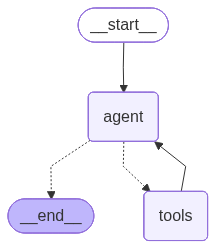

Graph saved → outputs/graph_N28.png


In [52]:
# --- LangGraph computation graph -------------------------------------------
from IPython.display import Image, display
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

try:
    _img = pit_strategy_react_agent.get_graph().draw_mermaid_png()
    display(Image(_img))
    with open("outputs/graph_N28.png", "wb") as _f:
        _f.write(_img)
    print("Graph saved → outputs/graph_N28.png")
except Exception as _e:
    print(f"graphviz not available — printing mermaid source: {_e}")
    print(pit_strategy_react_agent.get_graph().draw_mermaid())